# Benchmark Comparativo: CLIP vs CNN vs LLaVA

**Projeto:** DeepFashion AI - Catalogacao Inteligente
**Objetivo:** Avaliar e comparar todos os modelos de predicao de categoria no test set do DeepFashion.

Modelos avaliados:
- CLIP / Fashion-CLIP (zero-shot)
- CNN ResNet50 (transfer learning, treinada em DeepFashion)
- LLaVA via Ollama (multimodal local)

Metricas:
- Top-1 Accuracy
- Top-5 Accuracy
- Per-class Accuracy
- Tempo medio de inferencia


In [6]:
import sys
import os
import json
import time
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Setup concluido")

Project root: /home/eduardo/MIA/2/PROJ
Setup concluido


## 1. Carregar Test Set do DeepFashion

Usamos o split oficial do DeepFashion (`Eval/list_eval_partition.txt`) e as categorias coarse (`Anno_coarse/list_category_img.txt`).


In [7]:
from cnn_dataset import DeepFashionCategoryDataset, get_val_transforms, CAT_NAMES, NUM_CLASSES

DATA_ROOT = str(PROJECT_ROOT / "deepfashion")

test_ds = DeepFashionCategoryDataset(DATA_ROOT, split="test", transform=get_val_transforms())
print(f"Test set: {len(test_ds)} amostras")
print(f"{NUM_CLASSES} categorias")
print(f"\nPrimeiras 5 categorias:")
for i, name in enumerate(CAT_NAMES[:5]):
    print(f"  {i}: {name}")

[Dataset] Cache carregado: 40000 samples (test)
Test set: 40000 amostras
50 categorias

Primeiras 5 categorias:
  0: Anorak
  1: Blazer
  2: Blouse
  3: Bomber
  4: Button-Down


## 2. Amostra para Testes Rapidos (Opcional)

O test set completo tem 40.000 amostras. Para testes rapidos, podes usar uma amostra.
Para o benchmark final, usa o set completo.


In [8]:
USE_FULL_TESTSET = False  # Muda para True para test set completo
SAMPLE_SIZE = 500       # Tamanho da amostra

if USE_FULL_TESTSET:
    eval_indices = list(range(len(test_ds)))
    print(f"Usando test set completo: {len(eval_indices)} amostras")
else:
    import random
    random.seed(42)
    eval_indices = random.sample(range(len(test_ds)), SAMPLE_SIZE)
    print(f"Usando amostra: {len(eval_indices)} amostras")


Usando amostra: 500 amostras


## 3. Avaliar CLIP / Fashion-CLIP

Avalia todos os modelos CLIP zero-shot disponiveis.


In [9]:
from predictor import FashionPredictor

CLIP_MODELS = {
    "patrickjohncyh/fashion-clip": "Fashion-CLIP",
    "openai/clip-vit-base-patch32": "CLIP ViT-B/32",
    "openai/clip-vit-base-patch16": "CLIP ViT-B/16",
    "laion/CLIP-ViT-B-32-laion2B-s34B-b79K": "CLIP ViT-B/32 (LAION-2B)",
    "openai/clip-vit-large-patch14": "CLIP ViT-L/14",
}

def evaluate_clip(model_key, model_name, indices, use_tta=True):
    print(f"\nAvaliando: {model_name}")
    predictor = FashionPredictor(data_root=DATA_ROOT, model_name=model_key, use_tta=use_tta)
    
    correct_top1 = 0
    correct_top5 = 0
    times = []
    all_preds = []
    all_labels = []
    
    for idx in tqdm(indices, desc=model_name):
        img, label = test_ds[idx]
        img_path = test_ds.samples[idx]["path"]
        img_path_full = Path(DATA_ROOT) / img_path
        
        start = time.time()
        pred = predictor.predict(img_path_full, top_k=5, use_tta=use_tta)
        times.append(time.time() - start)
        
        pred_label = pred["category"]["label"]
        pred_top5 = [c["label"] for c in pred["category"]["top_k"]]
        true_label = CAT_NAMES[label]
        
        all_preds.append(pred_label)
        all_labels.append(true_label)
        
        if pred_label == true_label:
            correct_top1 += 1
        if true_label in pred_top5:
            correct_top5 += 1
    
    n = len(indices)
    results = {
        "model": model_name,
        "type": "CLIP",
        "top1_acc": correct_top1 / n,
        "top5_acc": correct_top5 / n,
        "avg_time": np.mean(times),
        "total_time": np.sum(times),
        "n_samples": n,
        "predictions": all_preds,
        "labels": all_labels,
    }
    
    print(f"  Top-1: {results['top1_acc']:.4f}")
    print(f"  Top-5: {results['top5_acc']:.4f}")
    print(f"  Tempo medio: {results['avg_time']*1000:.1f}ms")
    
    import torch
    del predictor
    torch.cuda.empty_cache()
    
    return results

clip_results = []
for key, name in CLIP_MODELS.items():
    try:
        res = evaluate_clip(key, name, eval_indices, use_tta=True)
        clip_results.append(res)
    except Exception as e:
        print(f"  Erro: {e}")



Avaliando: Fashion-CLIP
[Predictor] A carregar modelo patrickjohncyh/fashion-clip em cuda…


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


[Predictor] A construir text banks…
[Predictor] Pronto. 50 categorias, 554 atributos, 18 cores.


Fashion-CLIP: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:11<00:00, 43.38it/s]


  Top-1: 0.4380
  Top-5: 0.8700
  Tempo medio: 21.7ms

Avaliando: CLIP ViT-B/32
[Predictor] A carregar modelo openai/clip-vit-base-patch32 em cuda…
[Predictor] A construir text banks…
[Predictor] Pronto. 50 categorias, 554 atributos, 18 cores.


...

  Top-1: 0.3420
  Top-5: 0.7780
  Tempo medio: 37.4ms

Avaliando: CLIP ViT-B/32 (LAION-2B)
[Predictor] A carregar modelo laion/CLIP-ViT-B-32-laion2B-s34B-b79K em cuda…
[Predictor] A construir text banks…
[Predictor] Pronto. 50 categorias, 554 atributos, 18 cores.


CLIP ViT-B/32 (LAION-2B): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:11<00:00, 45.19it/s]


  Top-1: 0.4280
  Top-5: 0.8680
  Tempo medio: 20.8ms

Avaliando: CLIP ViT-L/14
[Predictor] A carregar modelo openai/clip-vit-large-patch14 em cuda…
[Predictor] A construir text banks…
[Predictor] Pronto. 50 categorias, 554 atributos, 18 cores.


CLIP ViT-L/14: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [01:07<00:00,  7.44it/s]

  Top-1: 0.3740
  Top-5: 0.7440
  Tempo medio: 126.9ms


## 4. Avaliar CNN (ResNet50)

Avalia a ResNet50 treinada em DeepFashion.


In [10]:
from cnn_predictor import CNNPredictor

CNN_CHECKPOINT = str(PROJECT_ROOT / "models" / "resnet50_best.pth")

def evaluate_cnn(checkpoint_path, indices):
    ckpt = Path(checkpoint_path)
    if not ckpt.exists():
        print(f"Checkpoint nao encontrado: {ckpt}")
        return None
    
    print(f"\nAvaliando: CNN ResNet50")
    predictor = CNNPredictor(checkpoint_path=ckpt, model_name="resnet50")
    
    correct_top1 = 0
    correct_top5 = 0
    times = []
    all_preds = []
    all_labels = []
    
    for idx in tqdm(indices, desc="CNN ResNet50"):
        img, label = test_ds[idx]
        img_path = test_ds.samples[idx]["path"]
        img_path_full = Path(DATA_ROOT) / img_path
        
        start = time.time()
        pred = predictor.predict(img_path_full, top_k=5)
        times.append(time.time() - start)
        
        pred_label = pred["category"]["label"]
        pred_top5 = [c["label"] for c in pred["category"]["top_k"]]
        true_label = CAT_NAMES[label]
        
        all_preds.append(pred_label)
        all_labels.append(true_label)
        
        if pred_label == true_label:
            correct_top1 += 1
        if true_label in pred_top5:
            correct_top5 += 1
    
    n = len(indices)
    results = {
        "model": "ResNet50",
        "type": "CNN",
        "top1_acc": correct_top1 / n,
        "top5_acc": correct_top5 / n,
        "avg_time": np.mean(times),
        "total_time": np.sum(times),
        "n_samples": n,
        "predictions": all_preds,
        "labels": all_labels,
    }
    
    print(f"  Top-1: {results['top1_acc']:.4f}")
    print(f"  Top-5: {results['top5_acc']:.4f}")
    print(f"  Tempo medio: {results['avg_time']*1000:.1f}ms")
    
    return results

cnn_result = evaluate_cnn(CNN_CHECKPOINT, eval_indices)
cnn_results = [cnn_result] if cnn_result else []



Avaliando: CNN ResNet50
[CNNPredictor] A carregar resnet50 de /home/eduardo/MIA/2/PROJ/models/resnet50_best.pth …
[CNNPredictor] Pronto. 50 categorias em cuda.


CNN ResNet50: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:02<00:00, 188.35it/s]

  Top-1: 0.6800
  Top-5: 0.9320
  Tempo medio: 4.1ms


## 5. Avaliar LLaVA via Ollama

Avalia o LLaVA local. Requer Ollama a correr.

**Nota:** LLaVA e muito mais lento. Considera usar uma amostra pequena.


In [11]:
from ollama_predictor import predict_with_ollama, OLLAMA_URL
import requests

def evaluate_llava(indices):
    try:
        r = requests.get(OLLAMA_URL.replace("/api/generate", ""), timeout=5)
        if r.status_code != 200:
            print("Ollama nao esta a correr. Ignorando LLaVA.")
            return None
    except:
        print("Ollama nao esta a correr. Ignorando LLaVA.")
        return None
    
    print(f"Avaliando: LLaVA via Ollama")
    correct_top1 = 0
    correct_top5 = 0
    times = []
    all_preds = []
    all_labels = []
    
    llava_indices = random.sample(indices, min(100, len(indices)))
    
    for idx in tqdm(llava_indices, desc="LLaVA"):
        img, label = test_ds[idx]
        img_path = test_ds.samples[idx]["path"]
        img_path_full = Path(DATA_ROOT) / img_path
        
        try:
            start = time.time()
            pred = predict_with_ollama(img_path_full)
            times.append(time.time() - start)
            
            pred_label = pred["category"]["label"]
            pred_top5 = [c["label"] for c in pred["category"].get("top_k", [])]
            true_label = CAT_NAMES[label]
            
            all_preds.append(pred_label)
            all_labels.append(true_label)
            
            if pred_label == true_label:
                correct_top1 += 1
            if true_label in pred_top5:
                correct_top5 += 1
        except Exception as e:
            print(f"Erro em {img_path}: {e}")
            all_preds.append("ERROR")
            all_labels.append(CAT_NAMES[label])
    
    n = len(llava_indices)
    results = {
        "model": "LLaVA",
        "type": "LLM",
        "top1_acc": correct_top1 / n,
        "top5_acc": correct_top5 / n,
        "avg_time": np.mean(times) if times else 0,
        "total_time": np.sum(times),
        "n_samples": n,
        "predictions": all_preds,
        "labels": all_labels,
    }
    
    print(f"  Top-1: {results['top1_acc']:.4f}")
    print(f"  Top-5: {results['top5_acc']:.4f}")
    print(f"  Tempo medio: {results['avg_time']*1000:.1f}ms")
    
    return results

llava_result = evaluate_llava(eval_indices)
llava_results = [llava_result] if llava_result else []


Avaliando: LLaVA via Ollama


LLaVA: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [10:32<00:00,  6.32s/it]

  Top-1: 0.2200
  Top-5: 0.2200
  Tempo medio: 6317.0ms


## 6. Agregar e Comparar Resultados


In [12]:
all_results = clip_results + cnn_results + llava_results

print(f"\nTotal de modelos avaliados: {len(all_results)}\n")

summary = []
for r in all_results:
    summary.append({
        "Modelo": r["model"],
        "Tipo": r["type"],
        "Top-1 Acc": f"{r['top1_acc']:.4f}",
        "Top-5 Acc": f"{r['top5_acc']:.4f}",
        "Tempo medio (ms)": f"{r['avg_time']*1000:.1f}",
        "Amostras": r["n_samples"],
    })

df_summary = pd.DataFrame(summary)
df_summary = df_summary.sort_values("Top-1 Acc", ascending=False)
display(df_summary)



Total de modelos avaliados: 7



,Modelo,Tipo,Top-1 Acc,Top-5 Acc,Tempo medio (ms),Amostras
5,ResNet50,CNN,0.6800,0.9320,4.1,500
0,Fashion-CLIP,CLIP,0.4380,0.8700,21.7,500
3,CLIP ViT-B/32 (LAION-2B),CLIP,0.4280,0.8680,20.8,500
4,CLIP ViT-L/14,CLIP,0.3740,0.7440,126.9,500
1,CLIP ViT-B/32,CLIP,0.3540,0.7740,21.5,500
2,CLIP ViT-B/16,CLIP,0.3420,0.7780,37.4,500
6,LLaVA,LLM,0.2200,0.2200,6317.0,100


## 7. Visualizacoes Comparativas


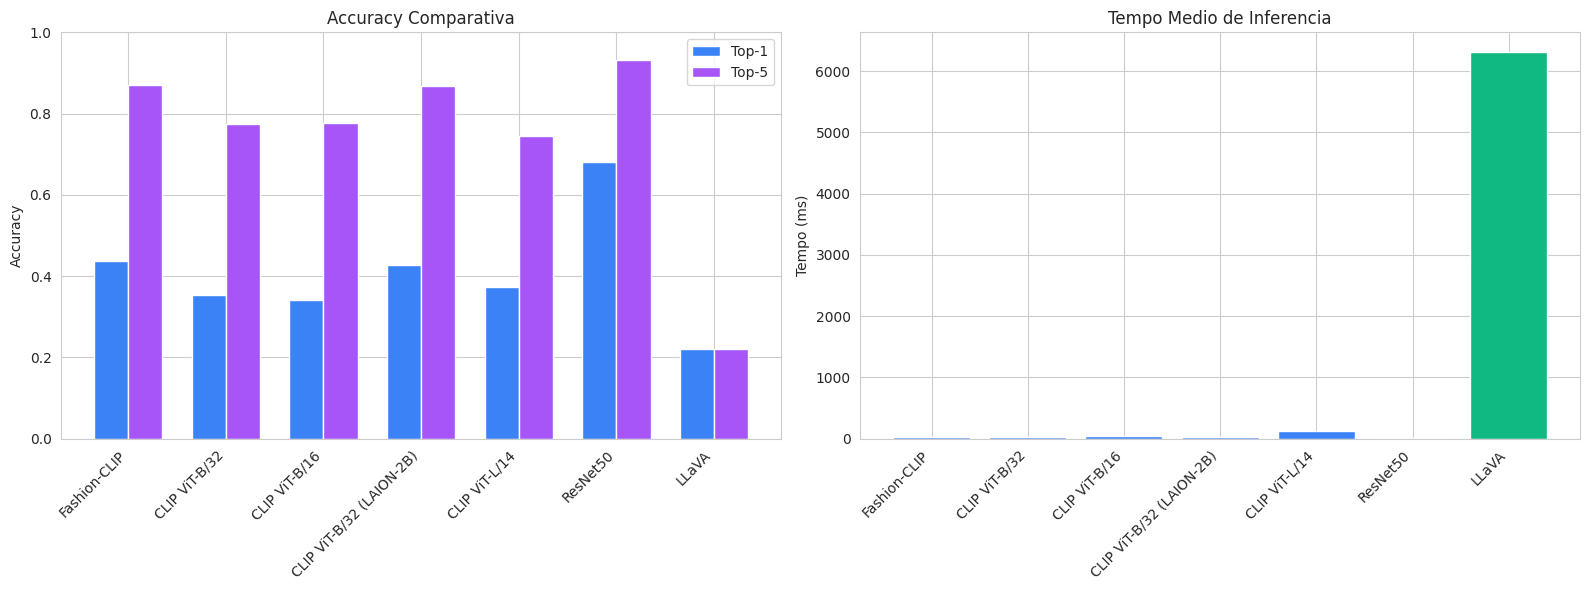

Grafico gravado: benchmark_comparison.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: Top-1 vs Top-5
models = [r["model"] for r in all_results]
top1 = [r["top1_acc"] for r in all_results]
top5 = [r["top5_acc"] for r in all_results]

x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, top1, width, label="Top-1", color="#3b82f6")
bars2 = axes[0].bar(x + width/2, top5, width, label="Top-5", color="#a855f7")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy Comparativa")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha="right")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Grafico 2: Tempo medio de inferencia
times_ms = [r["avg_time"]*1000 for r in all_results]
colors = ["#3b82f6" if r["type"]=="CLIP" else "#ef4444" if r["type"]=="CNN" else "#10b981" for r in all_results]
axes[1].bar(models, times_ms, color=colors)
axes[1].set_ylabel("Tempo (ms)")
axes[1].set_title("Tempo Medio de Inferencia")
axes[1].set_xticklabels(models, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("benchmark_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico gravado: benchmark_comparison.png")


## 8. Per-Class Accuracy


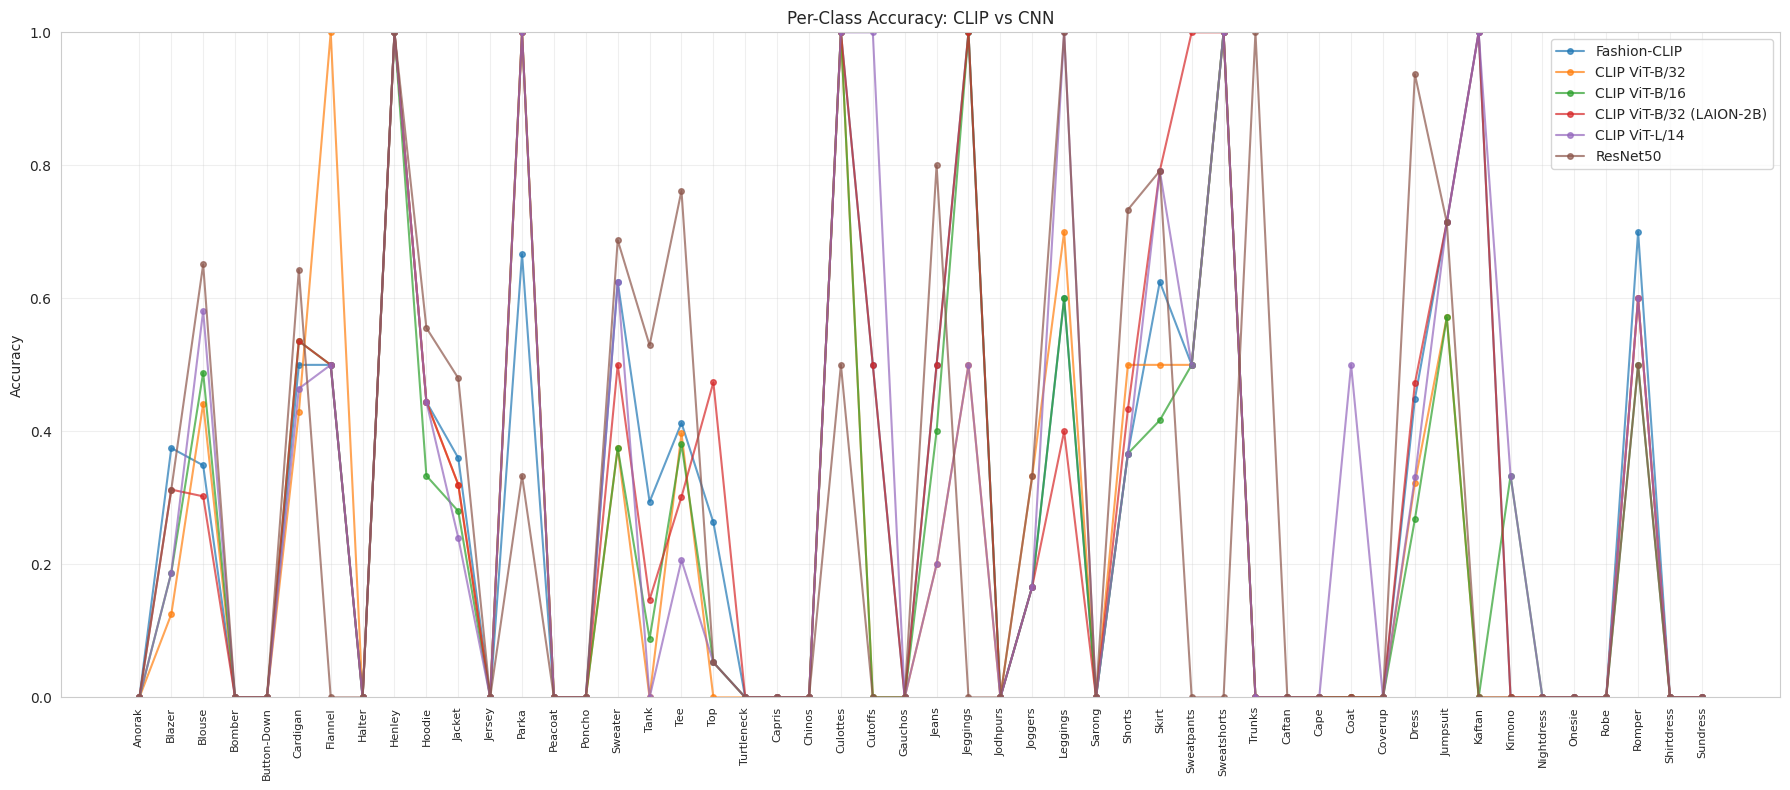

Grafico gravado: per_class_accuracy.png


In [14]:
def compute_per_class_accuracy(predictions, labels):
    class_correct = defaultdict(int)
    class_total = defaultdict(int)
    
    for pred, label in zip(predictions, labels):
        class_total[label] += 1
        if pred == label:
            class_correct[label] += 1
    
    return {cat: class_correct[cat] / class_total[cat] if class_total[cat] > 0 else 0
            for cat in CAT_NAMES}

fig, ax = plt.subplots(figsize=(18, 8))

for r in all_results:
    if r["type"] in ["CLIP", "CNN"]:
        per_class = compute_per_class_accuracy(r["predictions"], r["labels"])
        accs = [per_class[cat] for cat in CAT_NAMES]
        ax.plot(range(len(CAT_NAMES)), accs, "o-", label=r["model"], alpha=0.7, markersize=4)

ax.set_xticks(range(len(CAT_NAMES)))
ax.set_xticklabels(CAT_NAMES, rotation=90, fontsize=8)
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Accuracy: CLIP vs CNN")
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico gravado: per_class_accuracy.png")


## 9. Guardar Resultados


In [15]:
output = {
    "benchmark_date": pd.Timestamp.now().isoformat(),
    "test_samples": len(eval_indices),
    "models": [
        {
            "model": r["model"],
            "type": r["type"],
            "top1_acc": float(r["top1_acc"]),
            "top5_acc": float(r["top5_acc"]),
            "avg_time_ms": float(r["avg_time"]*1000),
            "n_samples": r["n_samples"],
        }
        for r in all_results
    ]
}

with open("benchmark_results.json", "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f"Resultados gravados: benchmark_results.json")
print(f"\nBenchmark concluido!")


Resultados gravados: benchmark_results.json

Benchmark concluido!
